In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from pathlib import Path
import tensorflow as tf
dataset_path = Path("/content/drive/MyDrive/Car-Bike-Dataset")

CLASS_NAMES = sorted([
    item.name for item in dataset_path.iterdir()
    if item.is_dir()
])

print("Classes:", CLASS_NAMES)
table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(CLASS_NAMES),
        values=tf.constant(list(range(len(CLASS_NAMES)))),
    ),
    default_value=-1
)

Classes: ['Bike', 'Car']


In [23]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.


In [24]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 4000 files belonging to 2 classes.
Using 800 files for validation.


In [25]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

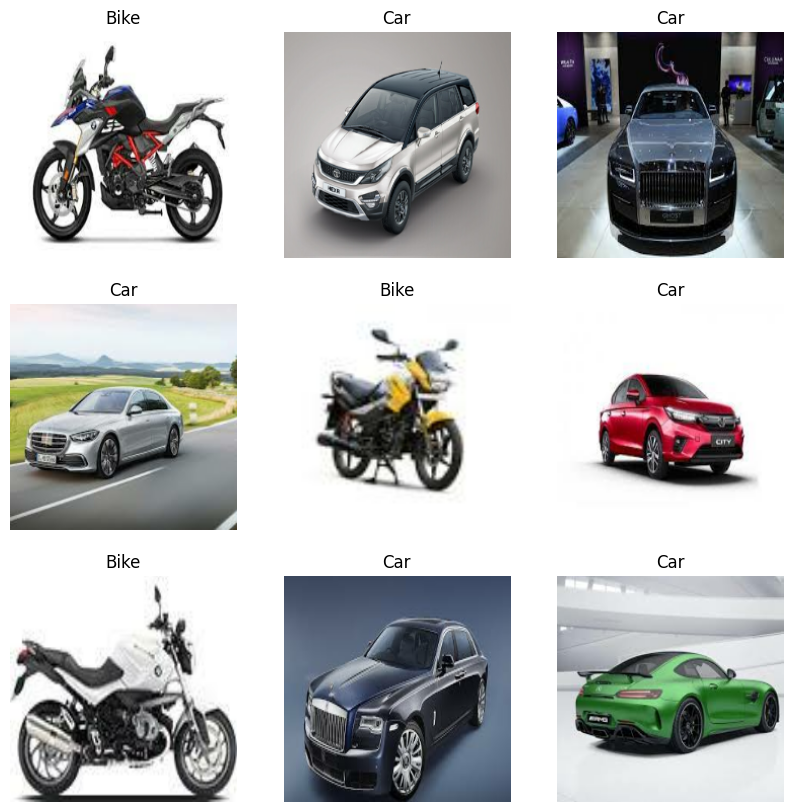

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title(CLASS_NAMES[labels[i]])

        plt.axis("off")

plt.show()

In [27]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    # Hidden Layer 1
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Hidden Layer 2
    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    # Output Layer
    tf.keras.layers.Dense(
        len(CLASS_NAMES),
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,915,778 (91.23 MB)

 Trainable params: 23,915,778 (91.23 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 92ms/step - accuracy: 0.7950 - loss: 0.5225 - val_accuracy: 0.8875 - val_loss: 0.2558
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step - accuracy: 0.9356 - loss: 0.1732 - val_accuracy: 0.9112 - val_loss: 0.2172
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.9694 - loss: 0.0733 - val_accuracy: 0.9200 - val_loss: 0.2423
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9875 - loss: 0.0376 - val_accuracy: 0.9237 - val_loss: 0.2796
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9825 - loss: 0.0469 - val_accuracy: 0.8900 - val_loss: 0.3364
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.9972 - loss: 0.0110 - val_accuracy: 0.9275 - val_loss: 0.3618
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9200 - val_loss: 0.4505
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 1.0000 - loss: 3.0025e-0

In [15]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.9212 - loss: 0.4172
Validation Accuracy: 0.9212499856948853


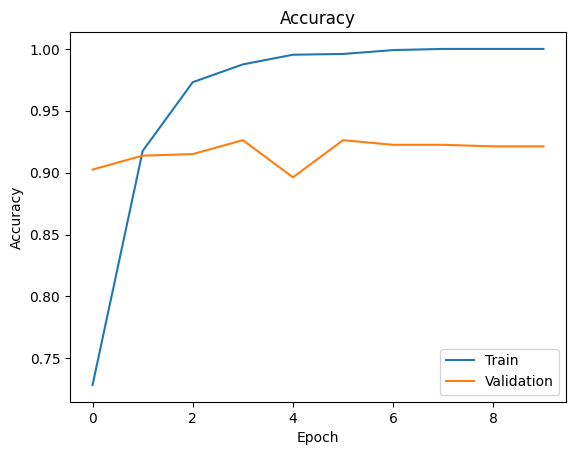

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

In [17]:
BATCH_SIZE = 16